In [69]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from kuramoto.config import (
    SimulationConfig,
    CouplingConfig,
    InitThetaConfig,
    InitOmegaConfig,
    build_simulation,
)

from kuramoto.plotting import (
    set_plot_settings,
    plot_abc_spread_boxplot_h,
)
from kuramoto.experiments import evaluate_metric_scores, aggregate_scores

import networkx as nx
from pathlib import Path

set_plot_settings()

# Import connectome
CONN_PATH = Path("..\\data\\OASIS_N272\\sub-OAS30001_ses-d0757_atlas-L2018_res-scale3_conndata-network_connectivity.graphml")
G = nx.read_graphml(CONN_PATH)

SEED = 42
K = 4

T_END = 20.0
dt = 0.1

RNG = np.random.default_rng(SEED)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [70]:
# Run sim
nodes = sorted(G.nodes())
A_bin = nx.to_numpy_array(G, nodelist=nodes)
A_density = nx.to_numpy_array(G, nodelist=nodes, weight="normalized_fiber_density")

# Normalize to 0-1 
A_density = A_density / A_density.max()

G_bin = nx.from_numpy_array(A_bin)
G_density = nx.from_numpy_array(A_density)

ncols, nrows = A_density.shape

N = A_density.shape[0]

cfg = SimulationConfig(
    coupling=CouplingConfig(
        K_matrix=A_density * K,
    ),
    initial_theta=InitThetaConfig(mode="uniform"),
    initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
    seed=SEED,
)

sim = build_simulation(config=cfg, rng=np.random.default_rng(SEED))

grid_shape = sim.grid.shape

# Run base simulation
res_base = sim.run((0, T_END), dt, rng=RNG)

### Seed-averaged lesion ensemble

  seed=42...
  seed=43...
  seed=44...
  seed=45...
  seed=46...

Done – 5 seeds.


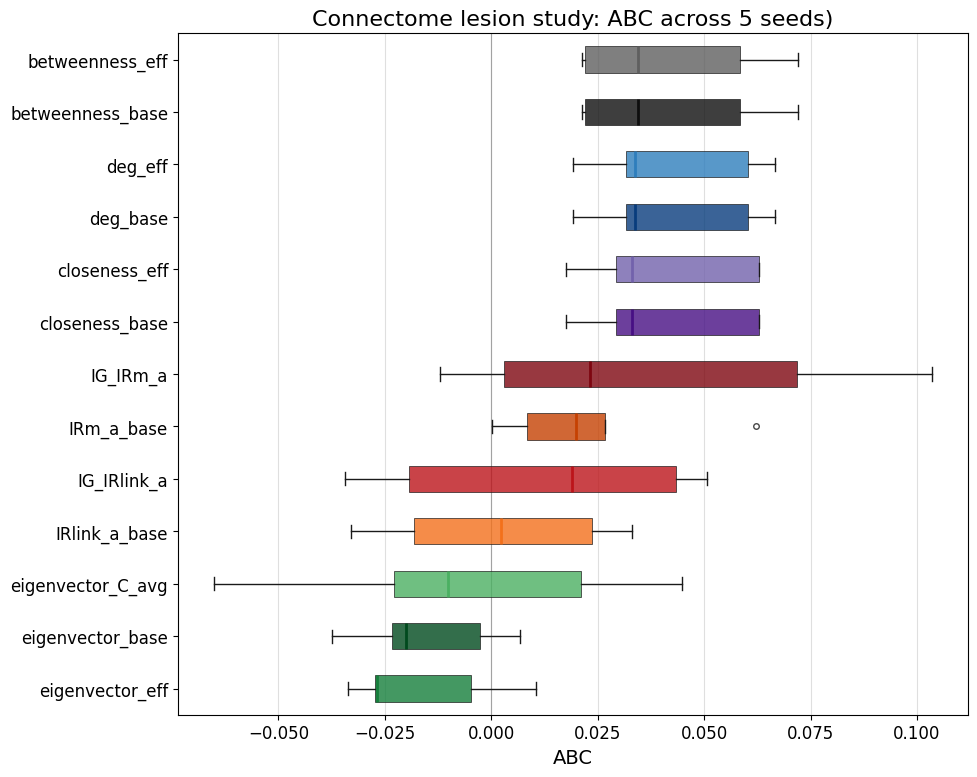

In [ ]:
N_SEEDS_ENSEMBLE = 5
BASE_SEED_ENSEMBLE = 42
ensemble_seeds = [BASE_SEED_ENSEMBLE + i for i in range(N_SEEDS_ENSEMBLE)]

N_RANDOM_REPEATS = 8
lesion_fracs = np.arange(0, 0.3, 0.02)
lesion_strength = 1.0
N_IG_STEPS = 20

connectome_results: dict[str, dict[int, dict]] = {"connectome": {}}

for seed in ensemble_seeds:
    print(f"  seed={seed}...")
    sim_s = build_simulation(config=cfg, rng=np.random.default_rng(seed))
    connectome_results["connectome"][seed] = evaluate_metric_scores(
        sim_s,
        T_END=T_END,
        dt=dt,
        RNG=np.random.default_rng(seed),
        n_random_repeats=N_RANDOM_REPEATS,
        lesion_fracs=lesion_fracs,
        lesion_strength=lesion_strength,
        n_ig_steps=N_IG_STEPS,
        verbose=False,
        base_seed=seed,
    )

print(f"\nDone – {N_SEEDS_ENSEMBLE} seeds.")

agg = aggregate_scores(connectome_results)
metrics_order = agg["connectome"]["metrics"]
abc_by_metric = {
    m: [connectome_results["connectome"][s][m]["ABC"] for s in ensemble_seeds]
    for m in metrics_order
}

fig, ax = plot_abc_spread_boxplot_h(
    abc_by_metric,
    title=f"Connectome lesion study: ABC across {N_SEEDS_ENSEMBLE} seeds",
    patch_alpha=0.8,
)
plt.show()